# Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from kmeans import CustomKMeans
from dbscan import CustomDBSCAN

In [2]:
RANDOM_STATE = 42

# KMeans

In [3]:
X, y_true = make_blobs(
    n_samples=1500,
    centers=4,
    n_features=2,
    cluster_std=1.3,
    random_state=RANDOM_STATE,
)

In [4]:
X = StandardScaler().fit_transform(X)

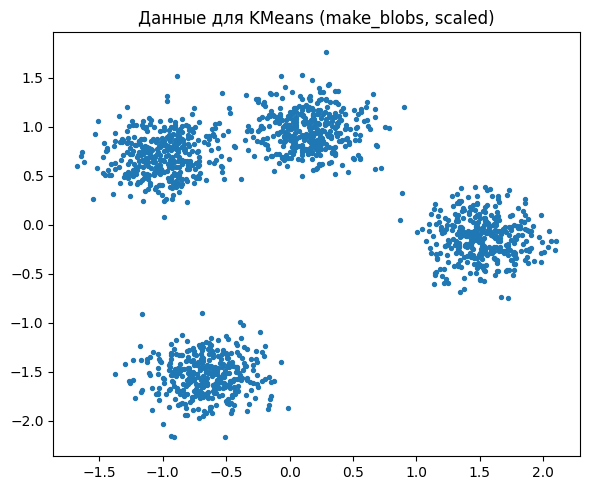

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=8)
plt.title("Данные для KMeans (make_blobs, scaled)")
plt.tight_layout()
plt.show()

## Обучение

In [6]:
params = dict(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=RANDOM_STATE,
)

In [7]:
custom_km = CustomKMeans(**params).fit(X)
sk_km = KMeans(
    n_clusters=params["n_clusters"],
    init=params["init"],
    n_init=params["n_init"],
    max_iter=params["max_iter"],
    tol=params["tol"],
    random_state=params["random_state"],
).fit(X)

In [8]:
ari_custom = adjusted_rand_score(y_true, custom_km.labels_)
ari_sklearn = adjusted_rand_score(y_true, sk_km.labels_)

In [9]:
sil_custom = silhouette_score(X, custom_km.labels_)
sil_sklearn = silhouette_score(X, sk_km.labels_)

print(f"KMeans | ARI custom={ari_custom:.4f} sklearn={ari_sklearn:.4f}")
print(f"KMeans | silhouette custom={sil_custom:.4f} sklearn={sil_sklearn:.4f}")
print(f"KMeans | inertia custom={custom_km.inertia_:.4f} sklearn={sk_km.inertia_:.4f}")
print(f"KMeans | n_iter custom={custom_km.n_iter_} sklearn={sk_km.n_iter_}")

KMeans | ARI custom=0.9912 sklearn=0.9912
KMeans | silhouette custom=0.7344 sklearn=0.7344
KMeans | inertia custom=144.9535 sklearn=144.9535
KMeans | n_iter custom=3 sklearn=3


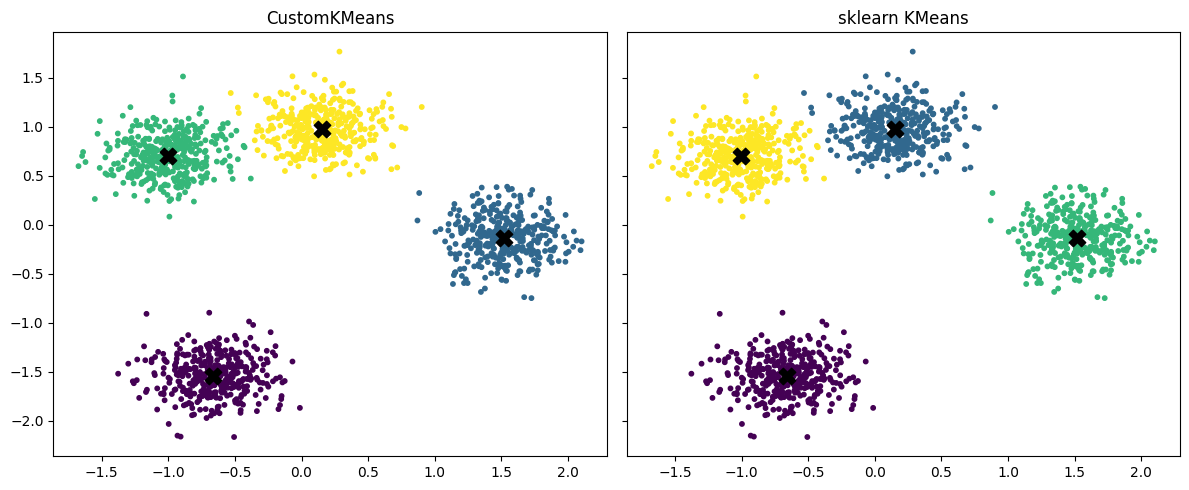

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=custom_km.labels_, s=10)
axes[0].scatter(custom_km.cluster_centers_[:, 0], custom_km.cluster_centers_[:, 1], c="black", s=140, marker="X")
axes[0].set_title("CustomKMeans")

axes[1].scatter(X[:, 0], X[:, 1], c=sk_km.labels_, s=10)
axes[1].scatter(sk_km.cluster_centers_[:, 0], sk_km.cluster_centers_[:, 1], c="black", s=140, marker="X")
axes[1].set_title("sklearn KMeans")

plt.tight_layout()
plt.show()

# DBSCAN

In [11]:
X, _ = make_moons(n_samples=1500, noise=0.07, random_state=RANDOM_STATE)
X = StandardScaler().fit_transform(X)

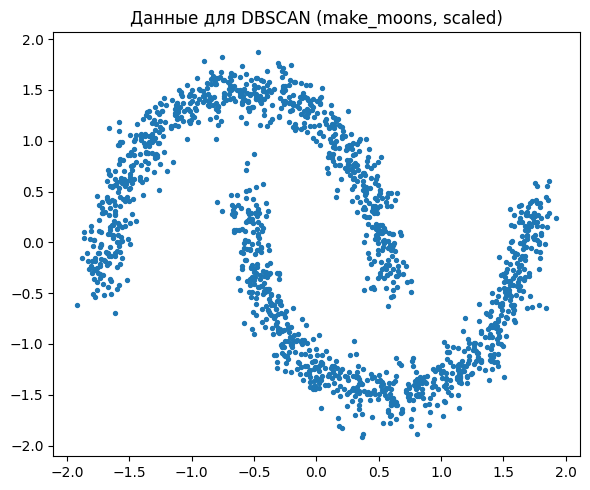

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=8)
plt.title("Данные для DBSCAN (make_moons, scaled)")
plt.tight_layout()
plt.show()

## Обучение

In [13]:
eps = 0.25
min_samples = 8

In [14]:
custom_db = CustomDBSCAN(eps=eps, min_samples=min_samples).fit(X)
sk_db = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean").fit(X)

In [15]:
ari_between = adjusted_rand_score(sk_db.labels_, custom_db.labels_)
print(f"DBSCAN | ARI(sklearn, custom)={ari_between:.4f}")
print(f"DBSCAN | noise points custom={int(np.sum(custom_db.labels_==-1))} sklearn={int(np.sum(sk_db.labels_==-1))}")

DBSCAN | ARI(sklearn, custom)=1.0000
DBSCAN | noise points custom=1 sklearn=1


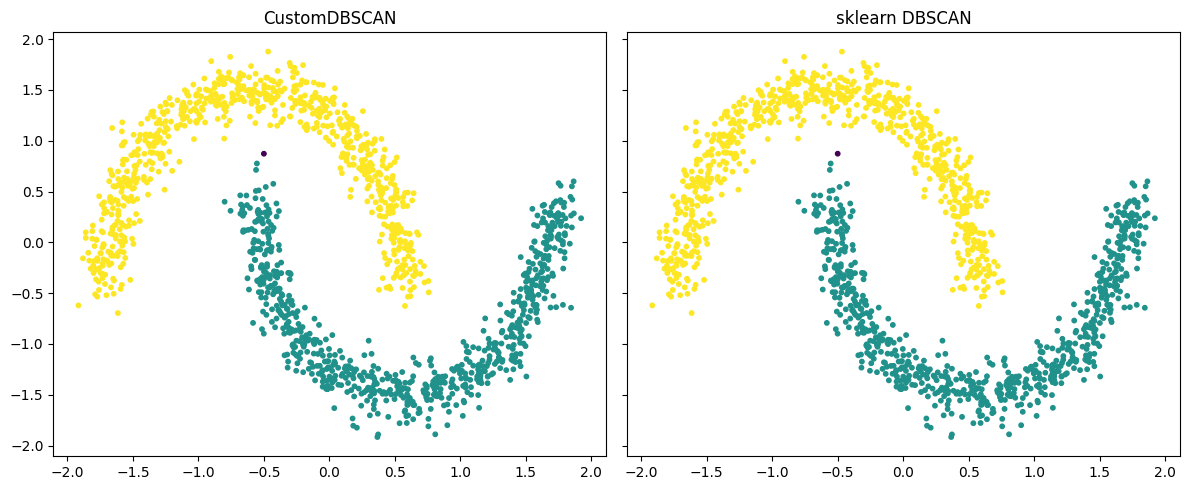

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=custom_db.labels_, s=10)
axes[0].set_title("CustomDBSCAN")

axes[1].scatter(X[:, 0], X[:, 1], c=sk_db.labels_, s=10)
axes[1].set_title("sklearn DBSCAN")

plt.tight_layout()
plt.show()